Dataset Shape: (1000, 8)

Columns:
 Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')

Missing Values:
 gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

Result Value Counts:
 result
1    865
0    135
Name: count, dtype: int64


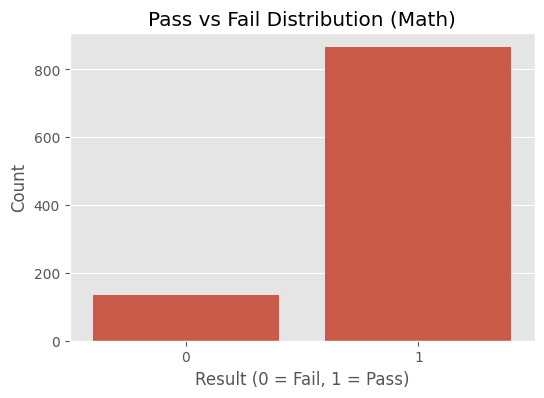

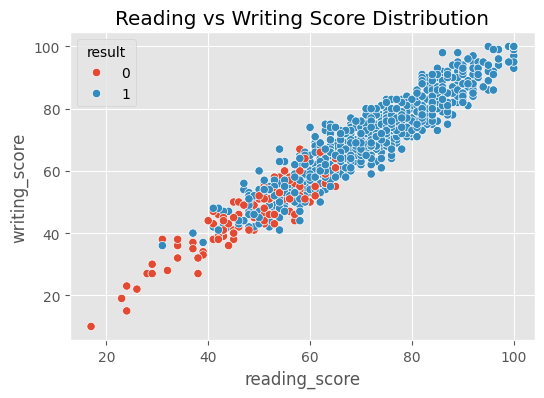

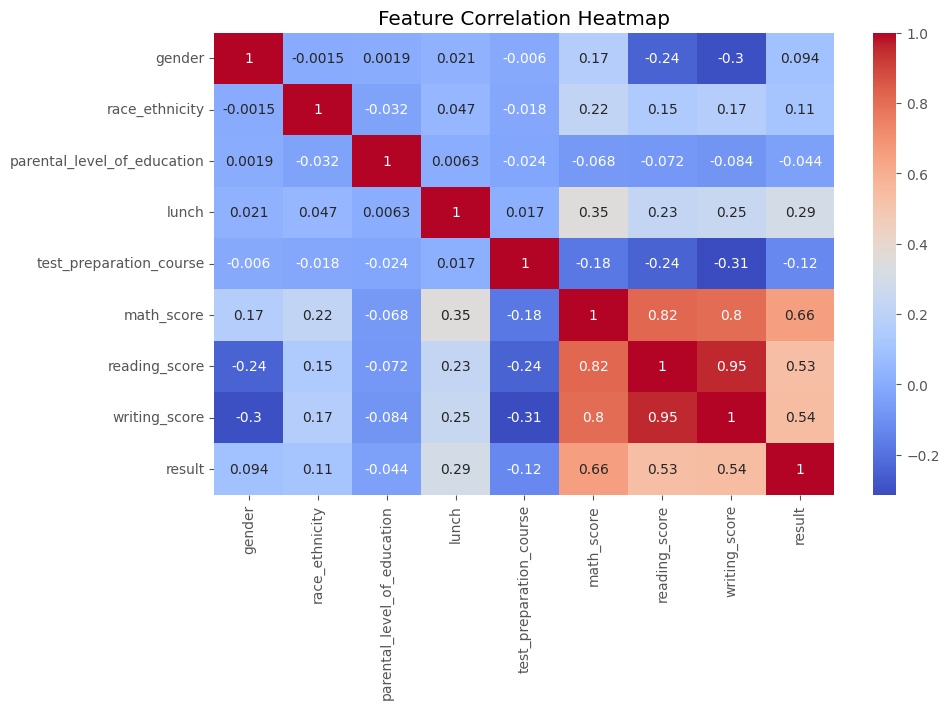

X_train: (800, 8)
X_test : (200, 8)


C:\Users\KLH\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model Accuracy: 0.99


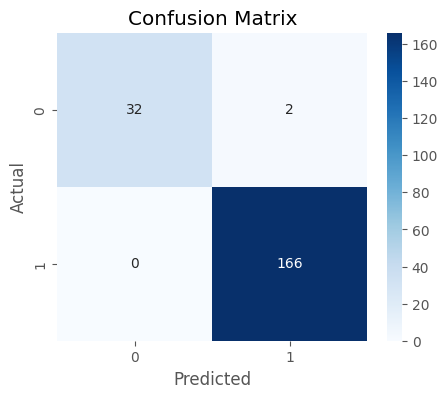


Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        34
           1       0.99      1.00      0.99       166

    accuracy                           0.99       200
   macro avg       0.99      0.97      0.98       200
weighted avg       0.99      0.99      0.99       200



In [1]:
# ==========================================
# 📌 Student Performance Prediction Project
# ==========================================

# 1️⃣ Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Set style for professional graphs
plt.style.use('ggplot')

# 2️⃣ Load Dataset
df = pd.read_csv("study_performance.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)

df.head()
# 3️⃣ Check Missing Values
print("\nMissing Values:\n", df.isnull().sum())

# 4️⃣ Create Result Column (Pass / Fail based on Math Score)
df['result'] = df['math_score'].apply(lambda x: 1 if x >= 50 else 0)

print("\nResult Value Counts:\n", df['result'].value_counts())
# 5️⃣ Convert Categorical → Numeric

le = LabelEncoder()

df['test_preparation_course'] = le.fit_transform(df['test_preparation_course'])
df['gender'] = le.fit_transform(df['gender'])
df['lunch'] = le.fit_transform(df['lunch'])
df['race_ethnicity'] = le.fit_transform(df['race_ethnicity'])
df['parental_level_of_education'] = le.fit_transform(df['parental_level_of_education'])
plt.figure(figsize=(6,4))
sns.countplot(x='result', data=df)
plt.title("Pass vs Fail Distribution (Math)")
plt.xlabel("Result (0 = Fail, 1 = Pass)")
plt.ylabel("Count")
plt.show()
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='reading_score',
    y='writing_score',
    hue='result',
    data=df
)
plt.title("Reading vs Writing Score Distribution")
plt.show()
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()
X = df.drop('result', axis=1)
y = df['result']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
model = LogisticRegression(max_iter=200)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
